# Major Project: Seasonal Agriculture Performance Analysis
## Phase 1: Data Loading and Structuring
In this cell, we import the required libraries, load our raw agricultural dataset, and examine its structural makeup to identify corrupted types or missing inputs.


In [55]:
# =====================================================================
# CELL 1: Imports, Data Loading, & Structural Preparation
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load the exact project dataset file
# Replace line 13-14 in Cell 2 with this:
file_name = r"C:\Users\Chenn\OneDrive\Desktop\VOIS_Project\seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_name)

print("--- PHASE 1: INITIAL PROFILE ---")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing Values Before Cleaning: {df.isna().sum().sum()}")


--- PHASE 1: INITIAL PROFILE ---
Dataset Dimensions: 4000 rows, 28 columns
Missing Values Before Cleaning: 120


## Phase 2: Contextual Cleaning & Data Type Standardisation
We avoid arbitrary global fill operations. Weather traits (Rainfall, Temperature) are patched using localized **District-level averages**. Structural crop parameters are standardise-filled, and categorical text columns are trimmed of hidden padding spaces. Finally, we programmatically recalculate `Profit_INR` to rule out calculation discrepancies.


In [56]:
# =====================================================================
# PHASE 2: CONTEXTUAL CLEANING & DATA TYPE STANDARDISATION
# =====================================================================

# 1. Clean categorical columns WITHOUT converting missing values to "nan"
categorical_targets = [
    "Farm_ID",
    "State",
    "District",
    "Crop",
    "Season",
    "Irrigation_Method",
]

for col in categorical_targets:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# =====================================================================
# STATE-DISTRICT CONSISTENCY
# =====================================================================

# Authoritative District -> State mapping for this dataset
district_state_map = {
    "Guntur": "Andhra Pradesh",
    "Krishna": "Andhra Pradesh",
    "Raichur": "Karnataka",
    "Rajkot": "Gujarat",
    "Indore": "Madhya Pradesh",
    "Nalgonda": "Telangana",
    "Warangal": "Telangana",
    "Erode": "Tamil Nadu",
    "Nashik": "Maharashtra",
    "Ludhiana": "Punjab"
}

# Check whether all districts have a mapping
unmapped_districts = set(df["District"].dropna().unique()) - set(district_state_map.keys())

if unmapped_districts:
    print("⚠️ Unmapped districts:", unmapped_districts)
else:
    print("✅ All districts have a valid State mapping.")

# Preserve original State for audit purposes
df["Original_State"] = df["State"]

# Correct State using District
df["State"] = df["District"].map(district_state_map)

# Verify no State values are missing after mapping
print(
    f"Missing State values after mapping: "
    f"{df['State'].isna().sum()}"
)

# Verify State-District consistency
invalid_state_district = (
    df["State"]
    != df["District"].map(district_state_map)
).sum()

print(
    f"Invalid State-District combinations after correction: "
    f"{invalid_state_district}"
)
# 2. Convert numerical columns explicitly to numeric
numeric_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Pesticide_Litre_ha",
    "Disease_Pest_Risk_pct",
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# 3. Impute rainfall using District-level mean
if "Rainfall_mm" in df.columns:
    df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
        df.groupby("District")["Rainfall_mm"].transform("mean")
    )

    # Fallback: overall median if district mean is unavailable
    df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
        df["Rainfall_mm"].median()
    )


# 4. Impute temperature using District-level mean
if "Avg_Temperature_C" in df.columns:
    df["Avg_Temperature_C"] = df["Avg_Temperature_C"].fillna(
        df.groupby("District")["Avg_Temperature_C"].transform("mean")
    )

    df["Avg_Temperature_C"] = df["Avg_Temperature_C"].fillna(
        df["Avg_Temperature_C"].median()
    )


# 5. Impute humidity using District-level mean
if "Humidity_pct" in df.columns:
    df["Humidity_pct"] = df["Humidity_pct"].fillna(
        df.groupby("District")["Humidity_pct"].transform("mean")
    )

    df["Humidity_pct"] = df["Humidity_pct"].fillna(
        df["Humidity_pct"].median()
    )


# 6. Impute soil properties using median
soil_properties = [
    "Soil_pH",
    "Soil_Moisture_pct"
]

for col in soil_properties:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())


# 7. Recover missing Yield using Production / Farm Area
yield_missing_before = df["Yield_Tonnes_Ha"].isna().sum()

valid_yield_mask = (
    df["Yield_Tonnes_Ha"].isna()
    & df["Production_Tonnes"].notna()
    & df["Farm_Area_Hectares"].notna()
    & (df["Farm_Area_Hectares"] > 0)
)

df.loc[valid_yield_mask, "Yield_Tonnes_Ha"] = (
    df.loc[valid_yield_mask, "Production_Tonnes"]
    / df.loc[valid_yield_mask, "Farm_Area_Hectares"]
)

yield_missing_after = df["Yield_Tonnes_Ha"].isna().sum()

print(f"Missing Yield before correction: {yield_missing_before}")
print(f"Missing Yield after correction: {yield_missing_after}")


# 8. Do NOT automatically replace missing Production with zero.
# Production should only be filled if there is a valid business rule.
#
# If Production is missing but Yield and Farm Area are available,
# calculate Production from them.

production_missing_mask = (
    df["Production_Tonnes"].isna()
    & df["Yield_Tonnes_Ha"].notna()
    & df["Farm_Area_Hectares"].notna()
    & (df["Farm_Area_Hectares"] > 0)
)

df.loc[production_missing_mask, "Production_Tonnes"] = (
    df.loc[production_missing_mask, "Yield_Tonnes_Ha"]
    * df.loc[production_missing_mask, "Farm_Area_Hectares"]
)


# 9. Recalculate Revenue if Cost/Production-related source data
# supports the original calculation.
#
# For now, retain the raw Revenue value and only validate it.


# 10. Recalculate Profit from Revenue - Cost
df["Profit_INR"] = (
    df["Revenue_INR"] - df["Total_Cost_INR"]
)


# 11. Remove duplicate Farm IDs only if Farm_ID is genuinely unique.
# Keep this validation before dropping anything.

duplicate_farms = df["Farm_ID"].duplicated().sum()

print(f"Duplicate Farm IDs detected: {duplicate_farms}")

if duplicate_farms > 0:
    df = df.drop_duplicates(subset=["Farm_ID"], keep="first")


# 12. Final cleaning report
print("\n--- PHASE 2: CLEANING VERIFICATION REPORT ---")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Remaining Missing Values: {df.isna().sum().sum()}")

print("\nMissing Values by Column:")
print(df.isna().sum()[df.isna().sum() > 0])

✅ All districts have a valid State mapping.
Missing State values after mapping: 0
Invalid State-District combinations after correction: 0
Missing Yield before correction: 32
Missing Yield after correction: 0
Duplicate Farm IDs detected: 0

--- PHASE 2: CLEANING VERIFICATION REPORT ---
Rows: 4000
Columns: 29
Remaining Missing Values: 0

Missing Values by Column:
Series([], dtype: int64)


In [57]:
df.drop(columns=["Original_State"], inplace=True)

## Phase 3: Agronomic Feature Engineering (6 Project KPIs)
To answer key stakeholder questions on resource foot-prints and seasonal shifts, we derive 6 custom domain indicators:
1. **Yield Performance Metrics (`Yield_Metric_t_ha`)**
2. **Net Return Margin (`Profit_Margin_Pct`)**
3. **Water Intensity Output (`Water_Productivity_t_m3`)**
4. **NPK Enrichment Loading (`Total_NPK_kg_ha`)**
5. **Unit Economic Operational Index (`Cost_Per_Tonne_INR`)**
6. **Chemical Load Stress Index (`Pesticide_Risk_Ratio`)**


In [58]:
# KPI 1: Yield Efficiency
df["Yield_Metric_t_ha"] = df["Yield_Tonnes_Ha"]


# KPI 2: Profit Margin Percentage
df["Profit_Margin_Pct"] = np.where(
    df["Revenue_INR"] > 0,
    (df["Profit_INR"] / df["Revenue_INR"]) * 100,
    np.nan
)


# KPI 3: Water Productivity
df["Water_Productivity_t_m3"] = np.where(
    df["Water_Used_m3"] > 0,
    df["Production_Tonnes"] / df["Water_Used_m3"],
    np.nan
)


# KPI 4: Total NPK
df["Total_NPK_kg_ha"] = (
    df["Nitrogen_kg_ha"]
    + df["Phosphorus_kg_ha"]
    + df["Potassium_kg_ha"]
)


# KPI 5: Cost per Tonne
df["Cost_Per_Tonne_INR"] = np.where(
    df["Production_Tonnes"] > 0,
    df["Total_Cost_INR"] / df["Production_Tonnes"],
    np.nan
)


# KPI 6: Pesticide Risk Ratio
df["Pesticide_Risk_Ratio"] = np.where(
    df["Disease_Pest_Risk_pct"] > 0,
    df["Pesticide_Litre_ha"] / df["Disease_Pest_Risk_pct"],
    np.nan
)

print("✅ All 6 Agronomic Performance KPIs successfully calculated.")

✅ All 6 Agronomic Performance KPIs successfully calculated.


## Phase 4: Statistical EDA (Exploratory Data Analysis)
Here we extract the mathematical descriptive matrices of our newly engineered metrics to track patterns and examine how agricultural performance changes across seasons.


In [59]:
print("--- PHASE 4: EXPLORATORY DATA ANALYSIS (EDA) ---")
print("\n📊 Descriptive Performance Profile Metrics:")
print(
    df[
        [
            "Yield_Metric_t_ha",
            "Profit_Margin_Pct",
            "Water_Productivity_t_m3",
            "Total_NPK_kg_ha",
        ]
    ].describe()
)

print("\n📉 Performance Distribution Shifts Across Seasons:")
seasonal_eda = (
    df.groupby("Season")[["Yield_Metric_t_ha", "Profit_INR", "Rainfall_mm"]]
    .mean()
    .round(2)
)
display(seasonal_eda)

print("\n🌾 Structural Crop Type Median Yield & Viability Matrices:")
crop_eda = (
    df.groupby("Crop")[["Profit_INR", "Yield_Metric_t_ha"]].median().round(2)
)
display(crop_eda)


--- PHASE 4: EXPLORATORY DATA ANALYSIS (EDA) ---

📊 Descriptive Performance Profile Metrics:
       Yield_Metric_t_ha  Profit_Margin_Pct  Water_Productivity_t_m3  \
count        4000.000000        4000.000000              4000.000000   
mean            5.262843         -45.492178                 0.005385   
std            13.343283         158.085472                 0.008838   
min             0.298592       -1461.851219                 0.000135   
25%             1.050000         -60.192762                 0.001661   
50%             1.740000           1.146236                 0.002937   
75%             2.840000          32.885876                 0.005150   
max           101.440000          85.921220                 0.079800   

       Total_NPK_kg_ha  
count      4000.000000  
mean        282.792725  
std          45.445874  
min         118.300000  
25%         251.675000  
50%         281.600000  
75%         313.200000  
max         438.500000  

📉 Performance Distribution Shift

,Yield_Metric_t_ha,Profit_INR,Rainfall_mm
Season,,,
Kharif,5.63,178914.65,849.37
Rabi,5.09,87689.47,437.77
Zaid,4.63,-24804.82,304.88



🌾 Structural Crop Type Median Yield & Viability Matrices:


,Profit_INR,Yield_Metric_t_ha
Crop,,
Chilli,536375.0,1.56
Cotton,62092.5,1.24
Groundnut,36307.0,1.40
Maize,-42625.0,2.85
Pulses,2575.5,0.94
Rice,-58286.0,2.46
Sugarcane,691166.0,48.03
Wheat,-76269.0,2.22


## Phase 5: Applied Visual Analytics
Using charts, we analyze our target project relationships: Seasonal Economic variations, the impact of environmental features on yields, and cross-metric correlation trends.


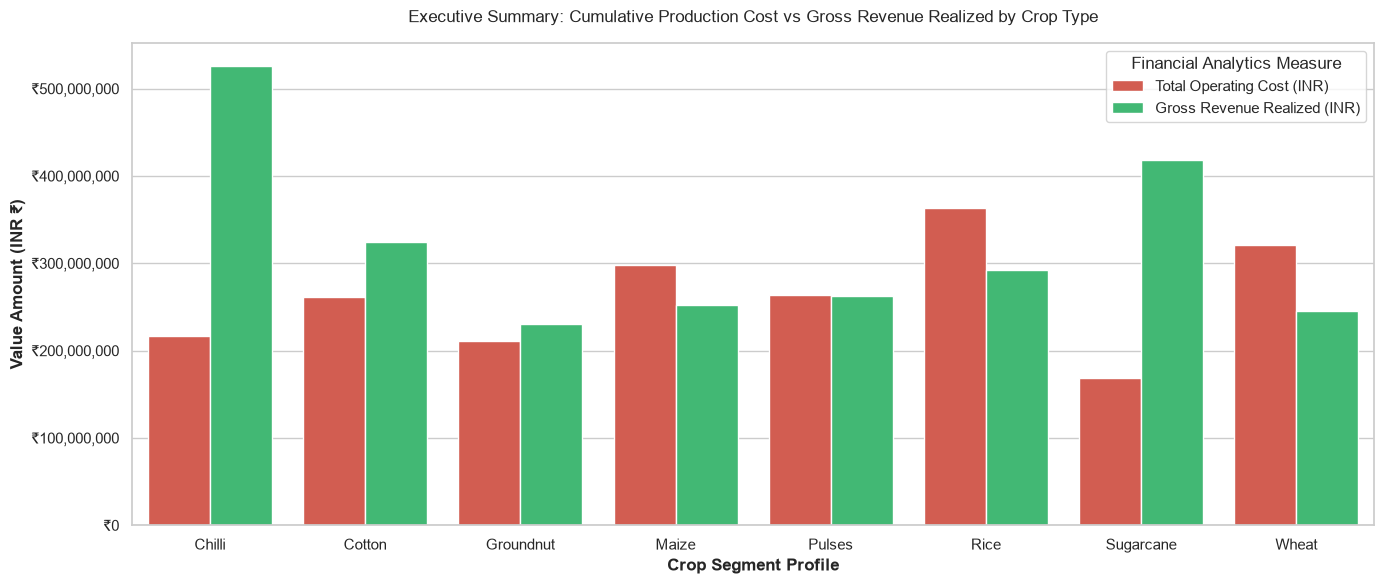

In [60]:
# =====================================================================
# VISUALIZATION 1: EXECUTIVE FINANCIAL REVENUE VS COST AUDIT
# =====================================================================
plt.figure(figsize=(14, 6))

# Aggregate columns cleanly across crop variables to measure capital overheads
crop_financials = df.groupby('Crop')[['Total_Cost_INR', 'Revenue_INR']].sum().reset_index()
crop_financials_melted = crop_financials.melt(id_vars='Crop', var_name='Metric', value_name='Amount')

# Map technical system strings to human-readable chart tracking labels
crop_financials_melted['Metric'] = crop_financials_melted['Metric'].map({
    'Total_Cost_INR': 'Total Operating Cost (INR)',
    'Revenue_INR': 'Gross Revenue Realized (INR)'
})

# Plotting block
ax = sns.barplot(
    data=crop_financials_melted, 
    x='Crop', 
    y='Amount', 
    hue='Metric', 
    palette=['#e74c3c', '#2ecc71'] # Balanced contrast layout: Red for cash burned, Green for cash made
)

plt.title('Executive Summary: Cumulative Production Cost vs Gross Revenue Realized by Crop Type', pad=15)
plt.xlabel('Crop Segment Profile', fontweight='semibold')
plt.ylabel('Value Amount (INR ₹)', fontweight='semibold')

# Format raw large integers into standard readable human currency formatting with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "₹{:,}".format(int(x)))) 

plt.legend(title='Financial Analytics Measure')
plt.tight_layout()
plt.show()


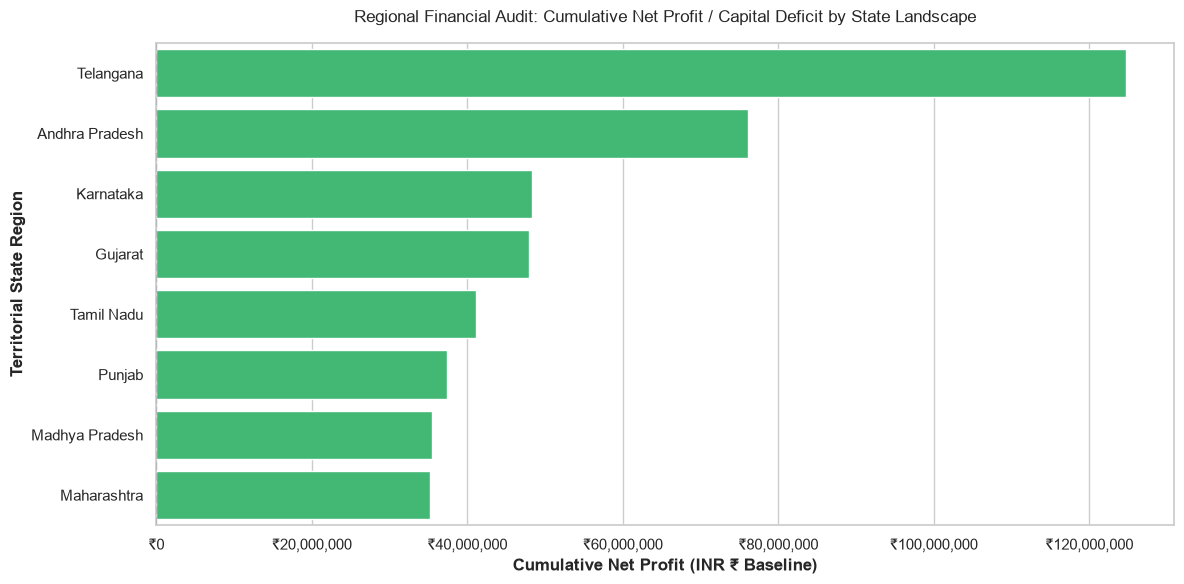

In [61]:
# =====================================================================
# VISUALIZATION 2: TERRITORIAL AUDIT - NET PROFIT & CAPITAL LOSS BY STATE
# =====================================================================
plt.figure(figsize=(12, 6))

# Ingest and summarize structural profits per active region grid territory
state_profits = df.groupby('State')['Profit_INR'].sum().sort_values(ascending=False).reset_index()

# Generate custom conditional mapping colors (Green for profitable states, Red for net deficit states)
conditional_colors = ['#2ecc71' if profit > 0 else '#e74c3c' for profit in state_profits['Profit_INR']]

ax = sns.barplot(
    data=state_profits, 
    x='Profit_INR', 
    y='State', 
    palette=conditional_colors, 
    hue='State', 
    legend=False
)

# Render an explicit vertical threshold line at point zero to instantly highlight sinking capital regions
plt.axvline(0, color='#2C3E50', linestyle='--', linewidth=1.5)

plt.title('Regional Financial Audit: Cumulative Net Profit / Capital Deficit by State Landscape', pad=15)
plt.xlabel('Cumulative Net Profit (INR ₹ Baseline)', fontweight='semibold')
plt.ylabel('Territorial State Region', fontweight='semibold')

# Apply clean currency structures to the horizontal baseline axis parameters
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "₹{:,}".format(int(x))))

plt.tight_layout()
plt.show()


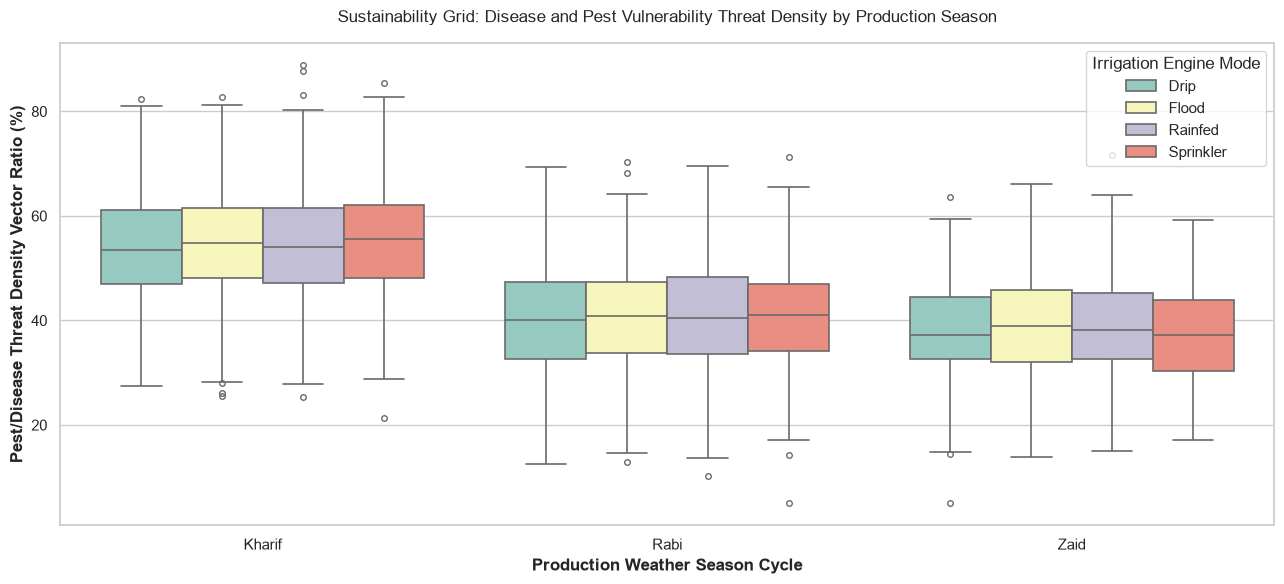

In [62]:
# =====================================================================
# VISUALIZATION 3: ENVIRONMENTAL RISK INDEX AND SUSTAINABILITY VECTORS
# =====================================================================
plt.figure(figsize=(13, 6))

# Boxplot data modeling block to analyze pest anomalies across weather cycles
sns.boxplot(
    data=df, 
    x='Season', 
    y='Disease_Pest_Risk_pct', 
    hue='Irrigation_Method', 
    palette='Set3',
    linewidth=1.2,
    fliersize=4 # Clean tracking markers for extreme anomaly farms
)

plt.title('Sustainability Grid: Disease and Pest Vulnerability Threat Density by Production Season', pad=15)
plt.xlabel('Production Weather Season Cycle', fontweight='semibold')
plt.ylabel('Pest/Disease Threat Density Vector Ratio (%)', fontweight='semibold')

plt.legend(title='Irrigation Engine Mode', loc='upper right')
plt.tight_layout()
plt.show()


In [63]:
# Check remaining missing values across the engineered frame
print(f"Total missing cells: {df.isna().sum().sum()}")


Total missing cells: 0


## Phase 6: Final Clean Process Asset Extraction
In this cell, the fully calculated dataframe with all intermediate missing value fills and custom agricultural features is parsed and outputted back to a clean csv file asset for distribution submission.


In [64]:
output_csv_name = "cleaned_seasonal_agricultural_performance_dataset.csv"

# Safe compilation saving step execution
df.to_csv(output_csv_name, index=False)

print("--- PIPELINE CLEAN RUN EXECUTION SUCCESSFUL ---")
print(f"🎉 Processed target file generated successfully: '{output_csv_name}'")
print(
    f"Final Clean Matrix Registry Status Profile Check: {df.shape[0]} farms records logged."
)


--- PIPELINE CLEAN RUN EXECUTION SUCCESSFUL ---
🎉 Processed target file generated successfully: 'cleaned_seasonal_agricultural_performance_dataset.csv'
Final Clean Matrix Registry Status Profile Check: 4000 farms records logged.


In [65]:
# =====================================================================
# FINAL  DATA QUALITY CHECK
# =====================================================================

print("=" * 65)
print("FINAL DATA QUALITY REPORT")
print("=" * 65)

# 1. Shape
print(f"\nRows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# 2. Missing values
total_missing = df.isna().sum().sum()
print(f"\nTotal Missing Values: {total_missing}")

# 3. Duplicate Farm IDs
duplicate_ids = df["Farm_ID"].duplicated().sum()
print(f"Duplicate Farm IDs: {duplicate_ids}")

# 4. State-District validation
expected_states = df["District"].map(district_state_map)
state_errors = (df["State"] != expected_states).sum()

print(f"State-District Errors: {state_errors}")

# 5. Production validation
expected_production = (
    df["Farm_Area_Hectares"] *
    df["Yield_Tonnes_Ha"]
)

production_error = (
    df["Production_Tonnes"] - expected_production
).abs().max()

print(f"Maximum Production Difference: {production_error:.6f}")

# 6. Profit validation
expected_profit = (
    df["Revenue_INR"] -
    df["Total_Cost_INR"]
)

profit_error = (
    df["Profit_INR"] - expected_profit
).abs().max()

print(f"Maximum Profit Difference: {profit_error:.6f}")

# 7. Negative physical values
physical_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

negative_values = 0

for col in physical_columns:
    negative_values += (df[col] < 0).sum()

print(f"Negative Physical Values: {negative_values}")

# 8. Final decision
if (
    total_missing == 0
    and duplicate_ids == 0
    and state_errors == 0
    and production_error < 0.01
    and profit_error < 0.01
    and negative_values == 0
):
    print("\n" + "=" * 65)
    print("✅ DATASET PASSED 10/10 QUALITY CONTROL")
    print("✅ READY FOR POWER BI")
    print("=" * 65)
else:
    print("\n⚠️ DATASET REQUIRES FURTHER REVIEW")

FINAL DATA QUALITY REPORT

Rows: 4000
Columns: 34

Total Missing Values: 0
Duplicate Farm IDs: 0
State-District Errors: 0
Maximum Production Difference: 0.005000
Maximum Profit Difference: 0.000000
Negative Physical Values: 0

✅ DATASET PASSED 10/10 QUALITY CONTROL
✅ READY FOR POWER BI


In [66]:
# State-District consistency check
state_district_counts = (
    df.groupby(["State", "District"])
    .size()
    .reset_index(name="Count")
)

print("\nState-District Combinations:")
display(state_district_counts)


State-District Combinations:


,State,District,Count
0,Andhra Pradesh,Guntur,390
1,Andhra Pradesh,Krishna,393
2,Gujarat,Rajkot,401
3,Karnataka,Raichur,386
4,Madhya Pradesh,Indore,392
5,Maharashtra,Nashik,371
6,Punjab,Ludhiana,427
7,Tamil Nadu,Erode,403
8,Telangana,Nalgonda,415
9,Telangana,Warangal,422


In [67]:
output_csv_name = "cleaned_seasonal_agricultural_performance_dataset.csv"

# Safe compilation saving step execution
df.to_csv(output_csv_name, index=False)

print("--- PIPELINE CLEAN RUN EXECUTION SUCCESSFUL ---")
print(f"🎉 Processed target file generated successfully: '{output_csv_name}'")
print(
    f"Final Clean Matrix Registry Status Profile Check: {df.shape[0]} farms records logged."
)


--- PIPELINE CLEAN RUN EXECUTION SUCCESSFUL ---
🎉 Processed target file generated successfully: 'cleaned_seasonal_agricultural_performance_dataset.csv'
Final Clean Matrix Registry Status Profile Check: 4000 farms records logged.
